In [1]:
import pandas as pd
from scipy.interpolate import splrep, BSpline
from scipy.stats import bootstrap
from scipy.signal import savgol_filter
from matplotlib import pyplot as plt
import numpy as np


In [2]:
Heisenberg_ground_states = {"5": -8.472135954999581,
                            "6": -11.21110255092798,
                            "7": -12.420717027386775,
                            "8": -14.604373635748704,
                            "9": -16.189199135748044,
                            }

In [3]:
def mean_std(df):
    df["mean"] = df.mean(axis=1)
    df["std"] = df.std(axis=1)
    mean_evals = df["mean"].to_numpy()
    std_evals = df["std"].to_numpy()

    return mean_evals, std_evals


def fit_curve(xx, vals, s):
    xnew = np.linspace(0, xx[-1], 1000)
    tckvals = splrep(xx, vals, s=s)
    vals_new = BSpline(*tckvals)(xnew)

    return xnew, vals_new


def mean_confidence_interval(data, confidence):
    res = bootstrap(
        data=(data,),
        statistic=np.mean,             # the estimator
        method="BCa",                  # asymmetric, bias-corrected & accelerated
        confidence_level = confidence,
        n_resamples=5000
    )

    ci_low, ci_high = res.confidence_interval.low, res.confidence_interval.high

    mean = data.mean()

    return mean, ci_low, ci_high


def compute_mean_and_confidence(df, runs, confidence):
    means = []
    lower_bounds = []
    upper_bounds = []

    for i, row in df.iterrows():
        #means.append(np.mean(row[:runs]))
        mean, lower_bound, upper_bound = mean_confidence_interval(data = row[:runs], confidence = confidence)
        
        means.append(mean)
        lower_bounds.append(lower_bound)
        upper_bounds.append(upper_bound)

    return np.array(means), np.array(lower_bounds), np.array(upper_bounds)


def compute_std(df, runs):
    stds = []
    for i, row in df.iterrows():
        stds.append(np.std(row[:runs]))

    return stds


## Rotosolve results

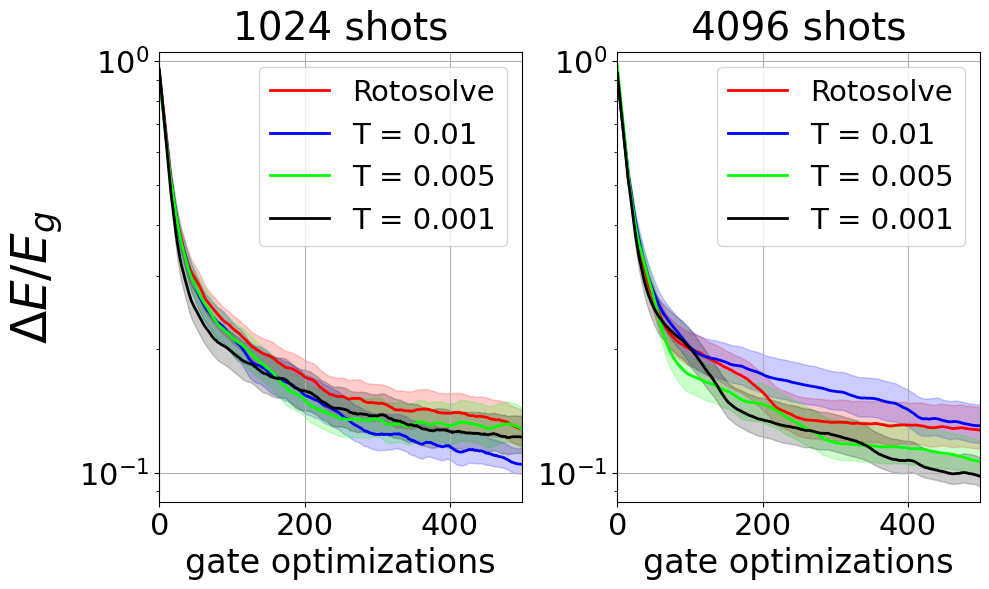

In [4]:
data_folder = f"../../data_folders/1DHeisenberg_5Q_data_noisy"


qubit = 5
iters = 25
layers = 2
trials = 30
shots_counts = [1024, 4096]

show_std = True
conf_level = 0.68

dvals = [0.01, 0.005, 0.001]

freeze_iters = ["inc"]

colors = ["blue", "lime", "black"]

fig, axes = plt.subplots(1, len(shots_counts))

fig.set_figheight(6)
fig.set_figwidth(10)

if len(shots_counts) == 1:
    axes = [axes]

every_n_row = 1

for shots, ax in zip(shots_counts, axes):
    df1 = pd.read_excel(f"{data_folder}/1DHeisenberg_{qubit}Q_rotosolve_{iters}cycles_{layers}layers_{trials}trials_{shots}shots.xlsx")
    df1 = np.abs((df1 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    df1 = df1.iloc[::every_n_row, :]
    
    mean1, lb1, ub1 = compute_mean_and_confidence(df1, runs=trials, confidence=conf_level)
    mean1 = savgol_filter(mean1, 30, 2)
    lb1 = savgol_filter(lb1, 30, 2)
    ub1 = savgol_filter(ub1, 30, 2)
    
    xx1 = np.arange(0, every_n_row*len(mean1), every_n_row)
    ax.plot(xx1, mean1, lw=2, color="red", label="Rotosolve")

    if show_std:
        ax.fill_between(xx1, ub1, lb1, alpha = 0.2, color="red")


    for d, color in zip(dvals, colors):
        df2 = pd.read_excel(f"{data_folder}/1DHeisenberg_{qubit}Q_rotosolve_GateFreeze_d{d}_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_{shots}shots.xlsx")
        
        df2 = np.abs((df2 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
        df2 = df2.iloc[::every_n_row, :]
        mean2, lb2, ub2 = compute_mean_and_confidence(df2, runs=trials, confidence=conf_level)
        mean2 = savgol_filter(mean2, 30, 2)
        lb2 = savgol_filter(lb2, 30, 2)
        ub2 = savgol_filter(ub2, 30, 2)

        xx = np.arange(0, every_n_row*len(mean2), every_n_row)

        ax.plot(xx, mean2, lw=2, color=color, label=f"T = {d}")

        if show_std:
            ax.fill_between(xx, ub2, lb2, alpha = 0.2, color=color)


    ax.set_title(f"{shots} shots", fontsize=28, y=1.01)
    ax.set_xlabel("gate optimizations", fontsize=24)
    ax.tick_params(labelsize=22)
    ax.set_xlim(0, max(xx1))
    ax.set_ylim(0.085, 1.05)
    ax.set_yscale("log")
    ax.grid()
    ax.legend(fontsize=21)

axes[0].set_ylabel(r"$\Delta E / E_g$", fontsize=35, labelpad=10)

fig.tight_layout()


# Fraxis results

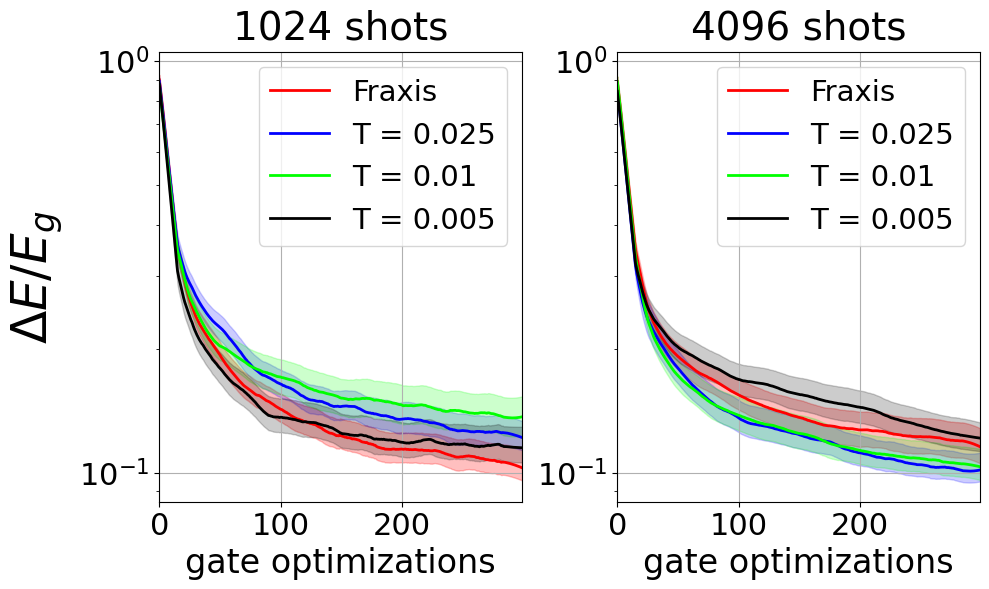

In [5]:
data_folder = f"../../data_folders/1DHeisenberg_5Q_data_noisy"

qubit = 5
iters = 20
layers = 3
trials = 30
shots_counts = [1024, 4096]

show_std = True
conf_level = 0.68

dvals = [0.025, 0.01, 0.005]

freeze_iters = ["inc"]

colors = ["blue", "lime", "black"]

fig, axes = plt.subplots(1, len(shots_counts))

fig.set_figheight(6)
fig.set_figwidth(10)

if len(shots_counts) == 1:
    axes = [axes]

every_n_row = 1

for shots, ax in zip(shots_counts, axes):
    df1 = pd.read_excel(f"{data_folder}/1DHeisenberg_{qubit}Q_Fraxis_{iters}cycles_{layers}layers_{trials}trials_{shots}shots.xlsx")
    df1 = np.abs((df1 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    df1 = df1.iloc[::every_n_row, :]
    
    mean1, lb1, ub1 = compute_mean_and_confidence(df1, runs=trials, confidence=conf_level)
    mean1 = savgol_filter(mean1, 30, 2)
    lb1 = savgol_filter(lb1, 30, 2)
    ub1 = savgol_filter(ub1, 30, 2)
    
    xx1 = np.arange(0, every_n_row*len(mean1), every_n_row)
    ax.plot(xx1, mean1, lw=2, color="red", label="Fraxis")

    if show_std:
        ax.fill_between(xx1, ub1, lb1, alpha = 0.25, color="red")


    for d, color in zip(dvals, colors):
        df2 = pd.read_excel(f"{data_folder}/1DHeisenberg_{qubit}Q_Fraxis_GateFreeze_GCdist_d{d}_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_{shots}shots.xlsx")
        
        df2 = np.abs((df2 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
        df2 = df2.iloc[::every_n_row, :]
        mean2, lb2, ub2 = compute_mean_and_confidence(df2, runs=trials, confidence=conf_level)
        mean2 = savgol_filter(mean2, 30, 2)
        lb2 = savgol_filter(lb2, 30, 2)
        ub2 = savgol_filter(ub2, 30, 2)
        xx = np.arange(0, every_n_row*len(mean2), every_n_row)

        ax.plot(xx, mean2, lw=2, color=color, label=f"T = {d}")

        if show_std:
            ax.fill_between(xx, ub2, lb2, alpha = 0.2, color=color)


    ax.set_title(f"{shots} shots", fontsize=28, y=1.01)
    ax.set_xlabel("gate optimizations", fontsize=24)
    ax.tick_params(labelsize=22)
    ax.set_xlim(0, max(xx1))
    ax.set_ylim(0.085, 1.05)
    ax.set_yscale("log")
    ax.grid()
    ax.legend(fontsize=21)

axes[0].set_ylabel(r"$\Delta E / E_g$", fontsize=35, labelpad=10)

fig.tight_layout()

# FQS results

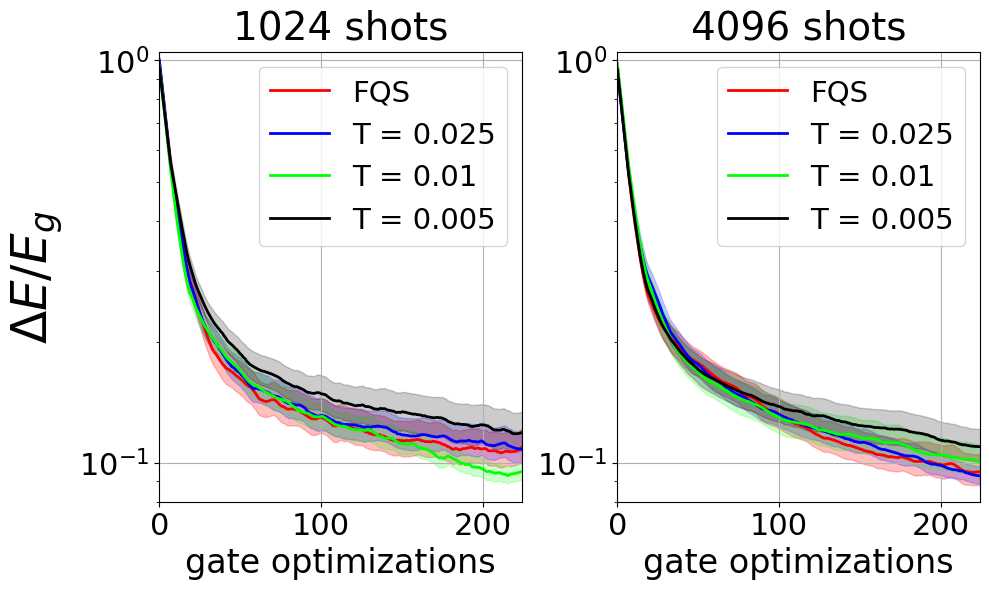

In [6]:
data_folder = f"../../data_folders/1DHeisenberg_5Q_data_noisy"

qubit = 5
iters = 15
layers = 3
trials = 30
shots_counts = [1024, 4096]

show_std = True
conf_level = 0.68

dvals = [0.025, 0.01, 0.005]

freeze_iters = ["inc"]

colors = ["blue", "lime", "black"]

fig, axes = plt.subplots(1, len(shots_counts))

fig.set_figheight(6)
fig.set_figwidth(10)

if len(shots_counts) == 1:
    axes = [axes]

every_n_row = 1

for shots, ax in zip(shots_counts, axes):
    df1 = pd.read_excel(f"{data_folder}/1DHeisenberg_{qubit}Q_FQS_{iters}cycles_{layers}layers_{trials}trials_{shots}shots.xlsx")
    df1 = np.abs((df1 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    df1 = df1.iloc[::every_n_row, :]
    
    mean1, lb1, ub1 = compute_mean_and_confidence(df1, runs=trials, confidence=conf_level)
    mean1 = savgol_filter(mean1, 15, 2)
    lb1 = savgol_filter(lb1, 15, 2)
    ub1 = savgol_filter(ub1, 15, 2)
    
    xx1 = np.arange(0, every_n_row*len(mean1), every_n_row)
    ax.plot(xx1, mean1, lw=2, color="red", label="FQS")

    if show_std:
        ax.fill_between(xx1, ub1, lb1, alpha = 0.25, color="red")


    for d, color in zip(dvals, colors):
        df2 = pd.read_excel(f"{data_folder}/1DHeisenberg_{qubit}Q_FQS_GateFreeze_GCdist_d{d}_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_{shots}shots.xlsx")
        
        df2 = np.abs((df2 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
        df2 = df2.iloc[::every_n_row, :]
        mean2, lb2, ub2 = compute_mean_and_confidence(df2, runs=trials, confidence=conf_level)
        mean2 = savgol_filter(mean2, 15, 2)
        lb2 = savgol_filter(lb2, 15, 2)
        ub2 = savgol_filter(ub2, 15, 2)
        xx = np.arange(0, every_n_row*len(mean2), every_n_row)

        ax.plot(xx, mean2, lw=2, color=color, label=f"T = {d}")

        if show_std:
            ax.fill_between(xx, ub2, lb2, alpha = 0.2, color=color)


    ax.set_title(f"{shots} shots", fontsize=28, y=1.01)
    ax.set_xlabel("gate optimizations", fontsize=24)
    ax.tick_params(labelsize=22)
    ax.set_xlim(0, max(xx1))
    ax.set_ylim(0.08, 1.05)
    ax.set_yscale("log")
    ax.grid()
    ax.legend(fontsize=21)

axes[0].set_ylabel(r"$\Delta E / E_g$", fontsize=35, labelpad=10)

fig.tight_layout()